In [7]:
import sys
import os 


from SYK_fft import *
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from ConformalAnalytical import *
from SUP_iterator_submission import *
from scipy.signal import find_peaks
import matplotlib.ticker as tck
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif"
})
# plt.style.use('../Figuremaker/physrev.mplstyle') # Set full path to if physrev.mplstyle is not in the same in directory as the notebook
# plt.rcParams['figure.dpi'] = "120"
# # plt.rcParams['legend.fontsize'] = '14'
plt.rcParams['legend.fontsize'] = '8'
plt.rcParams['figure.titlesize'] = '8'
plt.rcParams['axes.titlesize'] = '8'
plt.rcParams['axes.labelsize'] = '8'
# plt.rcParams['figure.figsize'] = f'{3.25*2},{3.25*2}'
plt.rcParams['lines.markersize'] = '6'
plt.rcParams['lines.linewidth'] = '1'
plt.rcParams['axes.formatter.limits'] = '-2,2'
plt.rcParams['text.usetex'] = 'True'
plt.rcParams['text.latex.preamble']=r"\usepackage{amsmath}"

In [8]:
DUMP = False

M = int(2**16) #number of points in the grid
T = 2**12 #upper cut-off for the time
#err = 1e-5
err = 1e-5


omega,t  = RealGridMaker(M,T)
dw = omega[2] - omega[1]
dt = t[2] - t[1]

print("dw = ", dw)
print("dt = ", dt)
print('omega max', np.max(omega))

delta = 0.420374134464041
ITERMAX = 15000 #changed this from 5000; this is because x is changed (x lower-> convergence is slower)!
global beta

mu = 0.0
g = .5
r = 1.
kappa = 1.
eta = dw*30.1
print("eta = ", eta)


dw =  0.000766990393941569
dt =  0.0625
omega max 50.26471546704275
eta =  0.023086410857641227


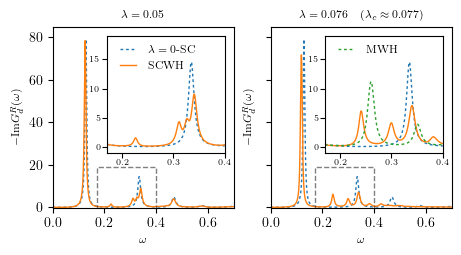

[0.12578642 0.22626217 0.3113981  0.32673791 0.34054373 0.40497093
 0.42031074 0.46786414 0.57831076 0.69949524 1.23178657 1.41126232]


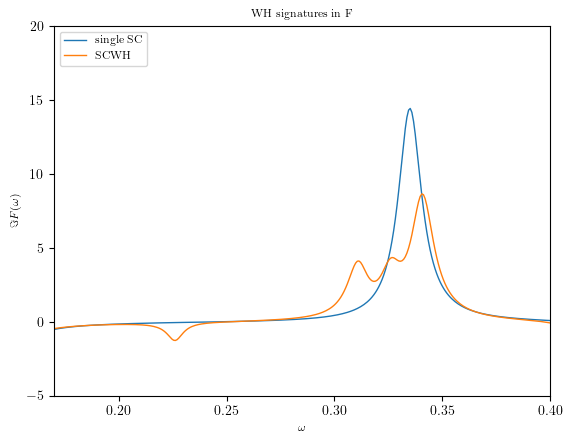

[0.25233984 0.35204859 0.43871851 0.46633016 0.59441756 0.65194183
 0.70716514 0.80917487 0.93266032 1.35833999 1.54701962 1.69504877
 1.87145656]
0.35204859081975465 (2.002379340632657e-05-5.850711914461808e-07j)
0.35204859081975465 (1.8114845900321248e-05-6.541039130317549e-06j)
0.35204859081975465


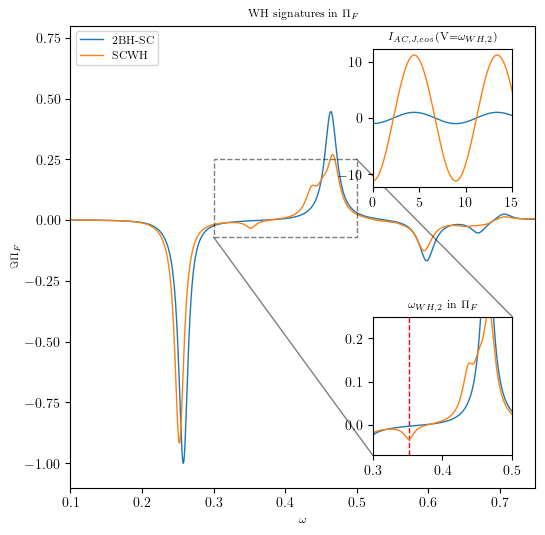

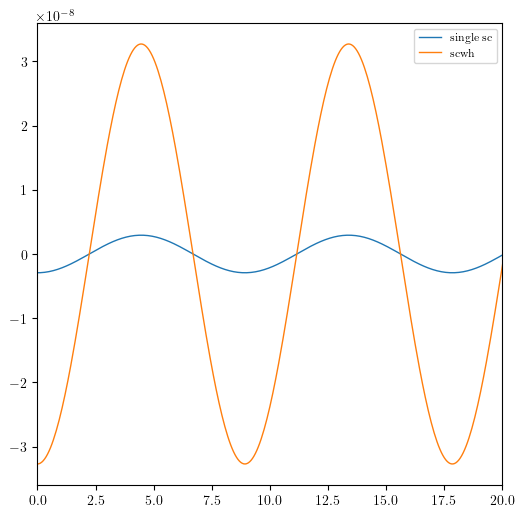

In [10]:

from matplotlib.legend_handler import HandlerLine2D
from matplotlib.lines import Line2D


GFs = np.load('trial5_ysykSUP_M16T12beta96_0g0_5r1_0eta12_1.npy') 
GFs_metal = np.load('mwh_M16T12beta96g0_5r1_0lamb0_05J0_0eta12_1.npy')
GFs_ = np.load('scwh_M16T12beta96g0_5r1_0lamb0_05J0_0eta12_1.npy')


fig, ax = plt.subplots(1,2, constrained_layout=True)
fig.set_size_inches(4.5, 4.5/1.5)

ax[0].plot(omega, -np.imag(GFs[0]), linestyle=(0, (2, 2)), label='$\lambda=0$ SC', c= 'tab:blue')
ax[0].plot(omega, -np.imag(GFs_[0]), label='SCWH', c= 'tab:orange')
ax[0].set_title(r'$\lambda = 0.05$')
ax[0].set_box_aspect(1)

axins = ax[0].inset_axes([0.3, 0.3, 0.65, 0.65]) # [x0, y0, width, height]
axins.plot(omega, -np.imag(GFs[0]), linestyle=(0, (2, 2)), label='$\lambda=0$-SC', c= 'tab:blue')
axins.plot(omega, -np.imag(GFs_[0]), label='SCWH', c= 'tab:orange')
axins.set_xlim(0.17, 0.4)
axins.set_ylim(-1, 19)
axins.set_box_aspect(1)
axins.tick_params(axis='both', labelsize=6, pad=1) 

axins.legend(loc = 'upper left', frameon=False, fontsize=8, handlelength=2,
    handler_map={Line2D: HandlerLine2D(numpoints=10)} ) 
rectpatch, connectors = ax[0].indicate_inset_zoom(axins, edgecolor="black", ls='dashed', )

# Remove the connecting lines
for line in connectors:
    line.set_visible(False)

ax[0].set_xlabel(r'$\omega$')
ax[0].set_ylabel(r'$-\text{Im} G_{d}^R(\omega)$')
ax[1].set_ylabel(r'$-\text{Im} G_{d}^R(\omega)$')
ax[0].set_xlim(0., .7)
ax[0].set_ylim(-.05, 85)

#right plot
GFs_ = np.load('scwh_M16T12beta96g0_5r1_0lamb0_076J0_0eta12_1.npy')
GFs_metal = np.load('mwh_M16T12beta96g0_5r1_0lamb0_076J0_0eta12_1.npy')
ax[1].plot(omega, -np.imag(GFs[0]), linestyle=(0, (2, 2)), label='scwh', c= 'tab:blue')
ax[1].plot(omega, -np.imag(GFs_[0]), label='mwh', c= 'tab:orange')
ax[1].set_box_aspect(1)
ax[1].set_ylim(0, 85)
ax[1].set_title(r'$\lambda = 0.076\quad (\lambda_c \approx 0.077)$')
ax[1].set_yticklabels([])
axins = ax[1].inset_axes([0.3, 0.3, 0.65, 0.65]) # [x0, y0, width, height]
axins.plot(omega, -np.imag(GFs[0]), linestyle=(0, (2, 2)), c= 'tab:blue')
axins.plot(omega, -np.imag(GFs_[0]),c= 'tab:orange')
axins.plot(omega, -np.imag(GFs_metal[0]),linestyle=(0, (2, 2)), label='MWH', c= 'tab:green')
axins.legend(loc = 'upper left', frameon=False, fontsize=8, handlelength=2,
    handler_map={Line2D: HandlerLine2D(numpoints=10)})
axins.set_xlim(0.17, 0.4)
axins.set_ylim(-1, 19)
axins.set_box_aspect(1)
axins.tick_params(axis='both', labelsize=6, pad=1) 


rectpatch, connectors = ax[1].indicate_inset_zoom(axins, edgecolor="black", ls='dashed', )
# Remove the connecting lines
for line in connectors:
    line.set_visible(False)


ax[1].set_xlabel(r'$\omega$')
ax[1].set_xlim(0, .7)
ax[1].set_ylim(-.05, 85)



plt.savefig('scwh_contributions_comb_new.pdf')
plt.show()
plt.close()


GFs_ = np.load('scwh_M16T12beta96g0_5r1_0lamb0_05J0_0eta12_1.npy')
plt.title('WH signatures in F')
plt.plot(omega, (np.imag(GFs[2])), label='single SC')
plt.plot(omega, (np.imag(GFs_[4])), label= 'SCWH')
peaks, _ = find_peaks(np.abs(np.imag(GFs_[4])), prominence=.002, height=.1)
omega_peaks = omega[peaks][omega[peaks]>0]
print(omega_peaks)

plt.xlim(0.17, .4)
plt.ylim(-5, 20)
plt.xlabel(r'$\omega$') 
plt.ylabel(r'$\Im F(\omega)$')
plt.legend(loc= 'upper left')
plt.savefig('whsignaturesF_inclJ.pdf')
plt.show()
plt.close()

lamb = 0.05
beta = 96
eta = .000001*dw
fdplus = np.array([fermidirac(beta*omegaval, default = False) for omegaval in omega])
fdminus = np.array([fermidirac(-1.0*beta*omegaval, default = False) for omegaval in omega])
beplus = np.array([boseeinstein(beta*omegaval, default = False) for omegaval in omega])
beminus = np.array([boseeinstein(-1.0*beta*omegaval, default = False) for omegaval in omega])
BMf = [fdplus, fdminus, beplus, beminus]

rhoF_ = -np.imag(GFs_[4])

plt.rcParams["figure.figsize"] = (6,6)
PiF_ = rhotoPiF(rhoF_, M, t, beta, BMf, eta)

rhoF = -np.imag(GFs[2])
PiF = rhotoPiF(rhoF, M, t, beta, BMf, eta)

plt.xlabel(r'$\omega$')
plt.ylabel(r'$\Im \Pi_F$')
plt.plot(omega, (np.imag(PiF))/np.max(np.abs(np.imag(PiF))), label= '2BH-SC')
plt.plot(omega, (np.imag(PiF_))/np.max(np.abs(np.imag(PiF))), label= 'SCWH')



peaks, _ = find_peaks(np.abs(np.imag(PiF_)), prominence=.0000002, height=0)
omega_peaks = omega[peaks][omega[peaks]>0]
print(omega_peaks)

plt.title('WH signatures in $\Pi_F$')
plt.ylim(-1.1, .8)
plt.legend(loc = 'upper left')

V = omega_peaks[1]
J = acjosephson(omega, lamb, V, PiF, t)
J_ = acjosephson(omega, lamb, V, PiF_, t)


#create an inset zooming in around 0.2, 0.4:
ax = plt.gca()
axins = ax.inset_axes([0.65, 0.07, 0.3, 0.3]) # [x0, y0, width, height]
print(V)
axins.axvline(V, c = 'red', ls= 'dashed')
axins.plot(omega, (np.imag(PiF))/np.max(np.abs(np.imag(PiF))), label='single SC')
axins.plot(omega, (np.imag(PiF_))/np.max(np.abs(np.imag(PiF))), label= 'SCWH')

axins.set_xlim(0.3, 0.5)
axins.set_ylim(-.07, 0.25) 
axins.set_title('$\omega_{WH, 2}$ in $\Pi_F$')
#show inset zoom 
ax.indicate_inset_zoom(axins, edgecolor="black", ls = 'dashed')




ax = plt.gca()

axins2 = ax.inset_axes([0.65, 0.65, 0.3, 0.3]) # [x0, y0, width, height]

axins2.set_title('$I_{AC, J, cos}$(V=$\omega_{WH, 2}$)')
axins2.plot(t, J/(np.max(J)), label='single SC')
axins2.plot(t, J_/(np.max(J)), label= 'SCWH')
axins2.set_xlim(0, 15)
# axins2.legend(loc = 'upper left')

plt.xlim(0.1, .75)
# plt.ylim(-.00025, .0002)
plt.savefig('whsignaturesPiFnoJ.pdf')
plt.show()
plt.close()



plt.plot(t, J, label = 'single sc')
plt.plot(t, J_, label = 'scwh')
plt.legend()
plt.xlim(0, 20)
plt.show()
plt.close()











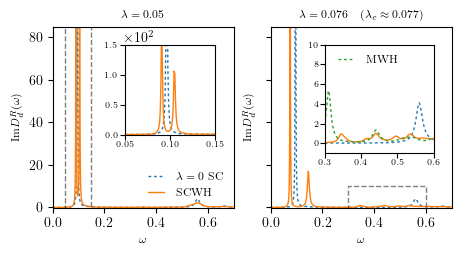

In [29]:
#BOSON 


from matplotlib.legend_handler import HandlerLine2D
from matplotlib.lines import Line2D


GFs = np.load('trial5_ysykSUP_M16T12beta96_0g0_5r1_0eta12_1.npy') 
GFs_metal = np.load('mwh_M16T12beta96g0_5r1_0lamb0_05J0_0eta12_1.npy')
GFs_ = np.load('scwh_M16T12beta96g0_5r1_0lamb0_05J0_0eta12_1.npy')


fig, ax = plt.subplots(1,2, constrained_layout=True)
fig.set_size_inches(4.5, 4.5/1.5)

ax[0].plot(omega, np.imag(GFs[1]), linestyle=(0, (2, 2)), label='$\lambda=0$ SC', c= 'tab:blue')
ax[0].plot(omega, np.imag(GFs_[2]), label='SCWH', c= 'tab:orange')
ax[0].set_title(r'$\lambda = 0.05$')
ax[0].set_box_aspect(1)

axins = ax[0].inset_axes([0.4, 0.4, 0.5, 0.5]) # [x0, y0, width, height]
axins.plot(omega, np.imag(GFs[1]), linestyle=(0, (2, 2)), label='$\lambda=0$-SC', c= 'tab:blue')
axins.plot(omega, np.imag(GFs_[2]), label='SCWH', c= 'tab:orange')
axins.set_xlim(0.05, 0.15)
axins.set_ylim(-1, 150)
axins.set_box_aspect(1)
axins.tick_params(axis='both', labelsize=6, pad=1) 

ax[0].legend(loc = 'lower right', frameon=False, fontsize=8, handlelength=2,
    handler_map={Line2D: HandlerLine2D(numpoints=10)} ) 
rectpatch, connectors = ax[0].indicate_inset_zoom(axins, edgecolor="black", ls='dashed', )

# Remove the connecting lines
for line in connectors:
    line.set_visible(False)

ax[0].set_xlabel(r'$\omega$')
ax[0].set_ylabel(r'$\text{Im} D_{d}^R(\omega)$')
ax[1].set_ylabel(r'$\text{Im} D_{d}^R(\omega)$')
ax[0].set_xlim(0., .7)
ax[0].set_ylim(-.05, 85)

#right plot
GFs_ = np.load('scwh_M16T12beta96g0_5r1_0lamb0_076J0_0eta12_1.npy')
GFs_metal = np.load('mwh_M16T12beta96g0_5r1_0lamb0_076J0_0eta12_1.npy')
ax[1].plot(omega, np.imag(GFs[1]), linestyle=(0, (2, 2)), label='scwh', c= 'tab:blue')
ax[1].plot(omega, np.imag(GFs_[2]), label='mwh', c= 'tab:orange')
ax[1].set_box_aspect(1)
ax[1].set_ylim(0, 85)
ax[1].set_title(r'$\lambda = 0.076\quad (\lambda_c \approx 0.077)$')
ax[1].set_yticklabels([])

axins = ax[1].inset_axes([0.3, 0.3, 0.6, 0.6]) # [x0, y0, width, height]
axins.plot(omega, np.imag(GFs[1]), linestyle=(0, (2, 2)), c= 'tab:blue')
axins.plot(omega, np.imag(GFs_[2]),c= 'tab:orange')
axins.plot(omega, np.imag(GFs_metal[2]),linestyle=(0, (2, 2)), label='MWH', c= 'tab:green')
axins.legend(loc = 'upper left', frameon=False, fontsize=8, handlelength=2,
    handler_map={Line2D: HandlerLine2D(numpoints=10)})
axins.set_xlim(0.3, 0.6)
axins.set_ylim(-1, 10)
axins.set_box_aspect(1)
axins.tick_params(axis='both', labelsize=6, pad=1) 


rectpatch, connectors = ax[1].indicate_inset_zoom(axins, edgecolor="black", ls='dashed', )
# Remove the connecting lines
for line in connectors:
    line.set_visible(False)


ax[1].set_xlabel(r'$\omega$')
ax[1].set_xlim(0, .7)
ax[1].set_ylim(-.05, 85)



plt.savefig('scwh_contributions_boson.pdf')
plt.show()
plt.close()
